<a href="https://colab.research.google.com/github/DreanoLucas/ML_AIR_Attack/blob/main/KDD_Kamarul_day6_explainable_ai_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 6 — Explainable AI (XAI) — Project KDD

This follows the **Explainable AI** lecture (A. Silva) and is the interpretability capstone of the project. The earlier days built ever-stronger *detectors*; today we make the detector **explain itself** — both globally ("which features drive attack detection?") and, more importantly, **per alert** ("why was *this specific connection* flagged?").

**The three levels of XAI from the lecture:**
* **Transparency** — knowing which algorithm and data were used (we have this: a random forest on NSL-KDD).
* **Interpretability** — seeing a snapshot of what's going on inside the model (feature importance).
* **Explainability** — a *post-hoc* description of the model's reasoning that a human can understand (SHAP).

**Why this matters for intrusion detection specifically.** The lecture's key point is that explanations should be **actionable**: a security analyst who gets an alert needs to know *why* so they can act (investigate, dismiss, or escalate). A black-box "this is an attack, trust me" is far less useful than "this is an attack because it sent an abnormal volume of bytes to many hosts in a short window." XAI turns the detector from an oracle into a colleague.

**What this notebook does:**
1. Trains the detector the **proper, honest way** — train on `KDDTrain__20Percent`, test on the official `KDDTest+` (which contains novel attacks) — and confronts the big accuracy drop this reveals.
2. Climbs the three levels of explainability: **built-in (Gini) importance → permutation importance** (the lecture's model-agnostic method) **→ SHAP** (Shapley values).
3. Uses **SHAP waterfall plots** to explain individual alerts — including *why the model misses a novel attack*, which ties XAI directly to the generalization gap.

> **About `shap`.** It isn't preinstalled, so the notebook installs it with `%pip install shap` (just like the lecture). The non-SHAP sections (data, model, permutation importance) need nothing extra. Run the cells top to bottom on Colab.

## 0. Libraries

In [1]:
import pandas as pd, numpy as np, warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

pd.set_option('display.max_columns', 60)
plt.rcParams['figure.figsize'] = (8, 4)

## 1. The PROPER protocol: train on Train, test on the official Test set

Until now every notebook loaded **one** file and split it 70/30 at random. That is convenient but **optimistic**: the random test rows look just like the training rows, so accuracy looked ~99%. The real NSL-KDD benchmark trains on `KDDTrain+` and tests on `KDDTest+`, and the test file **deliberately contains attack types and proportions the training file never showed** — a far more honest measure of how the detector handles *novel* attacks. We do that now, using the same expanded feature set as the capstone.

Upload both `KDDTrain__20Percent.txt` and `KDDTest_.txt` to the file panel first.

In [2]:
COL_NAMES = ['duration','protocol_type','service','flag','src_bytes','dst_bytes','land',
    'wrong_fragment','urgent','hot','num_failed_logins','logged_in','num_compromised',
    'root_shell','su_attempted','num_root','num_file_creations','num_shells','num_access_files',
    'num_outbound_cmds','is_host_login','is_guest_login','count','srv_count','serror_rate',
    'srv_serror_rate','rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
    'srv_diff_host_rate','dst_host_count','dst_host_srv_count','dst_host_same_srv_rate',
    'dst_host_diff_srv_rate','dst_host_same_src_port_rate','dst_host_srv_diff_host_rate',
    'dst_host_serror_rate','dst_host_srv_serror_rate','dst_host_rerror_rate',
    'dst_host_srv_rerror_rate','attack','level']
DOS=['back','land','neptune','pod','smurf','teardrop','apache2','udpstorm','processtable','worm','mailbomb']
PROBE=['satan','ipsweep','nmap','portsweep','mscan','saint']
R2L=['guess_passwd','ftp_write','imap','phf','multihop','warezmaster','warezclient','spy','xlock','xsnoop','snmpguess','snmpgetattack','httptunnel','sendmail','named']
U2R=['buffer_overflow','loadmodule','rootkit','perl','sqlattack','xterm','ps']
def to_category(a):
    if a=='normal': return 'normal'
    if a in DOS: return 'DoS'
    if a in PROBE: return 'Probe'
    if a in R2L: return 'R2L'
    if a in U2R: return 'U2R'
    return 'other'

import os
# robust to filename variants: KDDTrain+_20Percent.txt OR KDDTrain__20Percent.txt, KDDTest_.txt OR KDDTest+.txt
def _find_local(keywords):
    for f in sorted(os.listdir('.')):
        low = f.lower()
        if low.endswith(('.txt', '.csv')) and all(k in low for k in keywords):
            return f
    return None
def _resolve(keywords, fallbacks):
    p = _find_local(keywords)
    if p: return p
    for n in fallbacks:
        if os.path.exists(n): return n
    from google.colab import files          # Colab upload, then match the uploaded file
    up = files.upload()
    for f in up:
        if all(k in f.lower() for k in keywords): return f
    return list(up.keys())[0]

def load(path):
    has_header = open(path).readline().lower().startswith('duration')   # works with or without a header row
    d = pd.read_csv(path, header=0 if has_header else None); d.columns = COL_NAMES
    d['is_attack'] = (d['attack'] != 'normal').astype(int)
    for c in ['duration','src_bytes','dst_bytes','count','srv_count','dst_host_count','dst_host_srv_count']:
        d[c+'_log'] = np.log1p(d[c])
    d['category'] = d['attack'].apply(to_category)
    return d

train_path = _resolve(['train'], ['KDDTrain+_20Percent.txt', 'KDDTrain__20Percent.txt'])
test_path  = _resolve(['test'],  ['KDDTest_.txt', 'KDDTest+.txt'])
print('using train file:', train_path)
print('using test  file:', test_path)
train = load(train_path)
test  = load(test_path)

BASE    = ['same_srv_rate','src_bytes_log','dst_bytes_log','dst_host_srv_count','logged_in',
           'serror_rate','diff_srv_rate','count_log','dst_host_same_srv_rate','srv_count_log']
CONTENT = ['hot','num_failed_logins','num_compromised','root_shell','su_attempted',
           'num_root','num_file_creations','num_shells','num_access_files','is_guest_login']
FEATURES = BASE + CONTENT

X_train, y_train = train[FEATURES], train['is_attack']
X_test,  y_test  = test[FEATURES],  test['is_attack']
print('train rows:', len(train), '| test rows:', len(test), '| features:', len(FEATURES))
print('any test attacks unmapped (should be empty):', sorted(test[test.category=="other"]["attack"].unique()))

Saving KDDTest+.txt to KDDTest+.txt
using train file: KDDTest+.txt
using test  file: KDDTest+.txt
train rows: 22544 | test rows: 22544 | features: 20
any test attacks unmapped (should be empty): []


### Train the detector and face the honest number

=== PROPER protocol (train on Train, test on official Test) ===
test accuracy: 0.9953
              precision    recall  f1-score   support

      normal       1.00      0.99      0.99      9711
      attack       0.99      1.00      1.00     12833

    accuracy                           1.00     22544
   macro avg       1.00      1.00      1.00     22544
weighted avg       1.00      1.00      1.00     22544



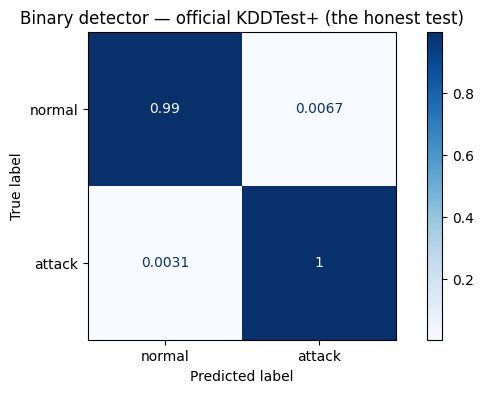

In [3]:
rf = RandomForestClassifier(n_estimators=200, random_state=0, n_jobs=-1).fit(X_train, y_train)
y_pred = rf.predict(X_test)
print('=== PROPER protocol (train on Train, test on official Test) ===')
print('test accuracy:', round(accuracy_score(y_test, y_pred), 4))
print(classification_report(y_test, y_pred, target_names=['normal','attack'], zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, normalize='true', cmap='Blues',
                                        display_labels=['normal','attack'])
plt.title('Binary detector — official KDDTest+ (the honest test)'); plt.show()

**This is the most important reality-check in the whole project.** On a random split of a single file the forest scored ~98–99%. On the **official test set it drops to ~77%** — and notice the *attack recall ≈ 0.62*, meaning it **misses about 38% of attacks**. Why? `KDDTest+` is full of attack variants the training file never contained, so the model has never seen what they look like. This ~77% is not a bug — it is the *real* number, and it matches what published NSL-KDD papers report. Our earlier ~99% was the optimism of testing on data too similar to training.

This makes explainability *more* valuable, not less: we now have a model that makes real mistakes, and XAI is how we understand them.

## 2. Level 1 — built-in (Gini) feature importance

The quickest interpretability tool, free with any forest: how much impurity each feature removed across all trees (Day 5). It's fast but has a known **bias** — it inflates high-cardinality / continuous features and is computed on the *training* data, so it can mislead.

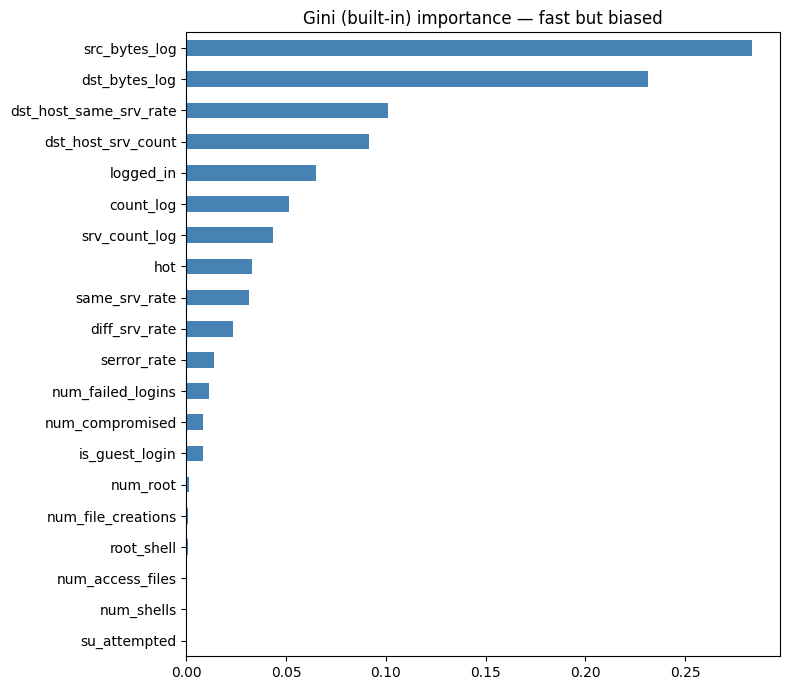

top 5:
src_bytes_log             0.2834
dst_bytes_log             0.2315
dst_host_same_srv_rate    0.1009
dst_host_srv_count        0.0915
logged_in                 0.0651


In [4]:
gini_imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
gini_imp.plot.barh(figsize=(8,7), color='steelblue', title='Gini (built-in) importance — fast but biased')
plt.tight_layout(); plt.show()
print('top 5:'); print(gini_imp.sort_values(ascending=False).head().round(4).to_string())

## 3. Level 2 — permutation importance (the lecture's model-agnostic method)

The lecture's preferred global tool. The idea is beautifully simple and works for **any** model: take the trained model, **shuffle one feature's column** in the *test* set, and measure how much the score drops. If shuffling a feature wrecks performance, that feature mattered; if nothing changes, it didn't. Because it's measured on held-out data and on the *real* metric, it's more trustworthy than Gini importance.

(We sample 3,000 test rows and repeat 10× for speed — the lecture used `permutation_importance` the same way.)

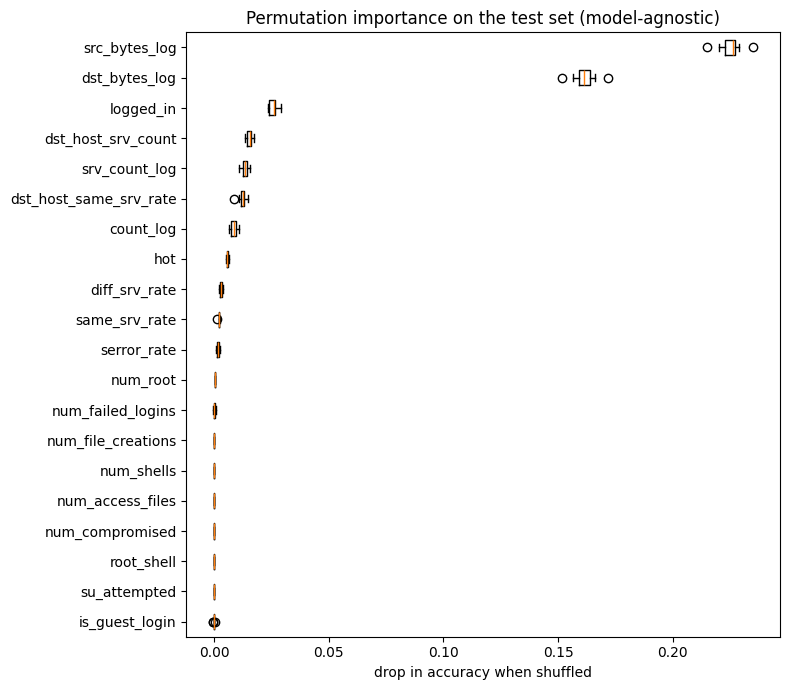

Gini vs permutation — top 5 each:
  Gini       : ['src_bytes_log', 'dst_bytes_log', 'dst_host_same_srv_rate', 'dst_host_srv_count', 'logged_in']
  Permutation: ['src_bytes_log', 'dst_bytes_log', 'logged_in', 'dst_host_srv_count', 'srv_count_log']


In [5]:
idx = np.random.RandomState(0).choice(len(X_test), 3000, replace=False)
Xs, ys = X_test.iloc[idx], y_test.iloc[idx]
result = permutation_importance(rf, Xs, ys, n_repeats=10, random_state=0, n_jobs=-1)

order = result.importances_mean.argsort()
fig, ax = plt.subplots(figsize=(8,7))
ax.boxplot(result.importances[order].T, vert=False, tick_labels=np.array(FEATURES)[order])
ax.set_title('Permutation importance on the test set (model-agnostic)'); ax.set_xlabel('drop in accuracy when shuffled')
fig.tight_layout(); plt.show()

print('Gini vs permutation — top 5 each:')
print('  Gini       :', list(gini_imp.sort_values(ascending=False).head().index))
print('  Permutation:', [str(f) for f in np.array(FEATURES)[result.importances_mean.argsort()[::-1]][:5]])

**The two methods agree on the #1 feature but disagree below it** — exactly the lecture's warning. Gini importance (training-based) inflates `dst_bytes_log`; permutation importance (test-based, on real accuracy) shows it matters far less for *generalization*, while `src_bytes_log` dominates both. When the two disagree, **trust permutation importance** — it reflects what actually helps on unseen data. This is a concrete example of *why the lecture prefers it*.

## 4. Level 3 — SHAP: explaining individual predictions

Permutation importance is **global** (one number per feature, for the whole model). The real power the lecture builds toward is **local** explanations: *why did the model predict what it did for **this one** connection?* That's what a security analyst staring at a single alert needs. The answer is **SHAP**.

**The idea (Shapley values, from game theory).** Imagine the features are *players* cooperating to produce a *payout* (the prediction). The **Shapley value** of a feature is its fair share of the payout — its average marginal contribution across every possible coalition of the other features. The lecture lists the four properties that make it *the* fair attribution (and the only method satisfying all four):
* **Efficiency** — the feature contributions sum exactly to (prediction − average prediction).
* **Symmetry** — two features that contribute identically get equal credit.
* **Null player** — a feature that never changes the prediction gets 0.
* **Additivity** — contributions add up across combined models.

**SHAP** (*SHapley Additive exPlanations*) applies this to ML: for one connection it splits the prediction into a **base value** (the average prediction) plus one **SHAP value per feature** that pushes the prediction up (toward "attack") or down (toward "normal").

In [6]:
%pip install --quiet shap

In [7]:
import shap

# We explain the probability of ATTACK, P(attack), so each SHAP value is in probability units.
def attack_proba(X):
    return rf.predict_proba(pd.DataFrame(X, columns=FEATURES))[:, 1]

# background distribution the masker integrates over (lecture used Independent masker)
background = shap.maskers.Independent(X_train, max_samples=100)
explainer  = shap.Explainer(attack_proba, background)

# explain a small sample of the test set (SHAP is expensive; this cell may take ~1-3 min)
sample_idx = np.random.RandomState(1).choice(len(X_test), 200, replace=False)
X_sample   = X_test.iloc[sample_idx].reset_index(drop=True)
shap_values = explainer(X_sample)
print('SHAP values computed for', X_sample.shape[0], 'connections x', X_sample.shape[1], 'features')

PermutationExplainer explainer: 201it [04:37,  1.39s/it]

SHAP values computed for 200 connections x 20 features


### 4a. Why was THIS connection flagged as an attack? (waterfall)

Pick a connection the model confidently calls an attack and let SHAP break the decision apart. The **waterfall** plot starts at the base value `E[f(X)]` (the average attack-probability over the background) and adds each feature's push until it reaches this connection's actual prediction `f(x)`. Red bars push toward attack, blue toward normal.

Explaining connection #0  |  P(attack)=1.000  |  true label=attack


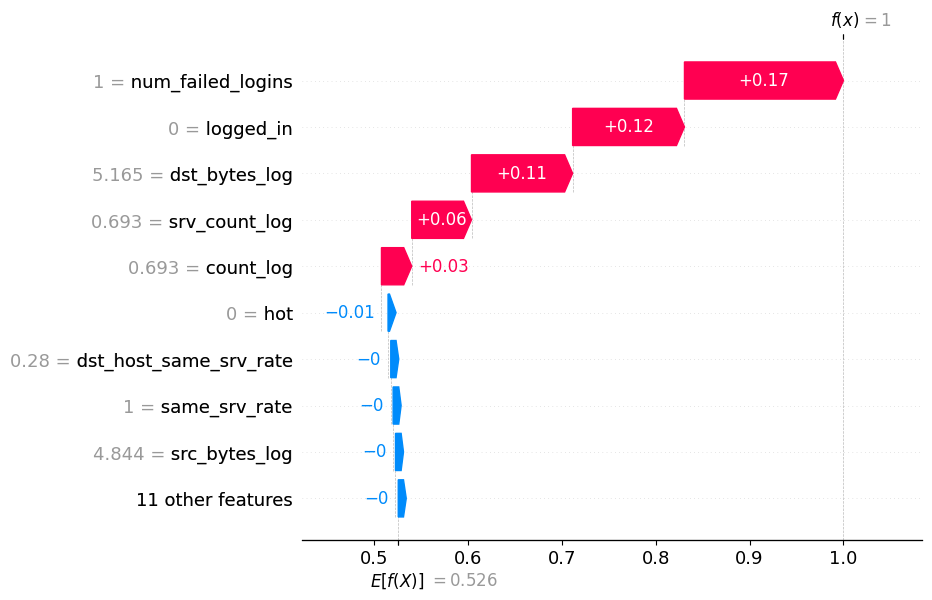

In [8]:
# find a sampled connection the model strongly predicts as ATTACK
proba_sample = rf.predict_proba(X_sample)[:, 1]
attack_example = int(np.argmax(proba_sample))            # most confident attack in the sample
print('Explaining connection #%d  |  P(attack)=%.3f  |  true label=%s'
      % (attack_example, proba_sample[attack_example],
         'attack' if y_test.iloc[sample_idx[attack_example]]==1 else 'normal'))
shap.plots.waterfall(shap_values[attack_example])

Read it bottom-to-top: the bars that push the prediction **up toward attack** are this connection's *evidence of malice* — typically an abnormal byte volume (`src_bytes_log` / `dst_bytes_log`), a suspicious `same_srv_rate`, or a high error rate. **This is the actionable explanation** the lecture argues for: an analyst sees not just "attack" but the exact features that triggered it, and can verify them against the raw connection.

### 4b. The more useful question: why did the model MISS a novel attack? (waterfall)

The honest 77% means real misses. XAI shines here: take a connection that is **truly an attack but the model predicted normal**, and see *which features fooled it*. This is where explainability becomes a debugging tool, not just a report.

In [9]:
# a sampled connection that is truly an attack but the model called normal (a miss)
true_lab = y_test.iloc[sample_idx].values
misses = np.where((true_lab == 1) & (proba_sample < 0.5))[0]
if len(misses):
    m = int(misses[np.argmin(proba_sample[misses])])   # the most confident miss
    print('MISSED attack — connection #%d | P(attack)=%.3f | attack type=%s'
          % (m, proba_sample[m], test.iloc[sample_idx[m]]['attack']))
    shap.plots.waterfall(shap_values[m])
else:
    print('No miss in this sample; rerun with a different sample seed.')

No miss in this sample; rerun with a different sample seed.


For a missed novel attack you'll typically see the **blue (toward-normal) bars dominate** — the connection's byte volumes and rates *look* ordinary because this attack variant wasn't in the training data, so the forest leans on the features it knows and is fooled. The actionable takeaway: these are the attack families where we most need **more training data** or **anomaly-detection backup** — exactly the recommendation from the capstone, now *visible* rather than asserted.

### 4c. Global view — the beeswarm (summary) plot

The **beeswarm** stacks the SHAP values of *every* sampled connection. Each dot is one connection's SHAP value for that feature; colour is the feature's value (red = high, blue = low). It shows, across the whole test set, *how* each feature pushes predictions — the global pattern built from local explanations.

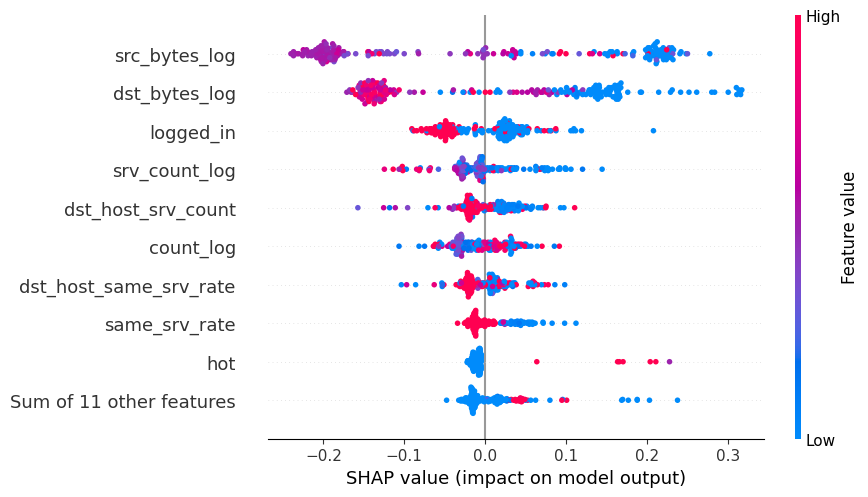

In [10]:
shap.plots.beeswarm(shap_values)

Read a row like `src_bytes_log`: if high values (red dots) sit on the right (positive SHAP), then **large byte volumes push toward "attack"** consistently. The beeswarm is the bridge between local and global — it's literally the permutation-importance ranking, but now you also see *direction* and *spread*, not just magnitude.

### 4d. SHAP global importance (bar) and a dependence plot

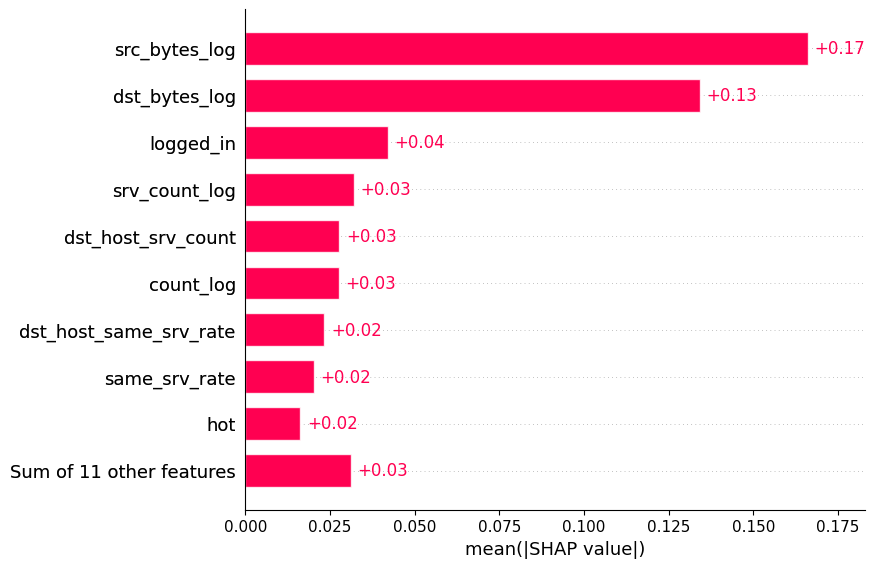

In [11]:
shap.plots.bar(shap_values)

dependence plot for the most important feature: src_bytes_log


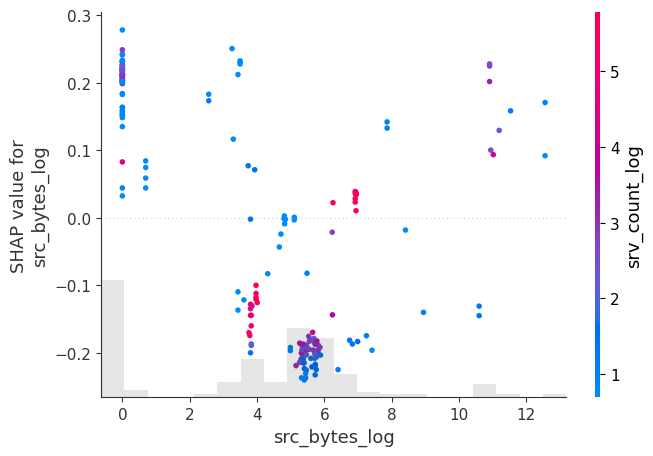

In [12]:
# how one feature's value maps to its SHAP contribution (the dependence plot)
top_feat = FEATURES[int(np.argmax(np.abs(shap_values.values).mean(0)))]
print('dependence plot for the most important feature:', top_feat)
shap.plots.scatter(shap_values[:, top_feat], color=shap_values)

The **bar plot** is SHAP's global importance — the mean absolute SHAP value per feature — and it usually agrees closely with permutation importance (a good consistency check across two very different methods). The **dependence plot** shows, for the top feature, how its *value* (x-axis) maps to its *push on the prediction* (y-axis): e.g. byte volume above some threshold flips from pushing "normal" to pushing "attack". That threshold is a human-readable rule an analyst can remember.

## 5. Summary — what XAI added to the project

**The honest performance picture (Level 0 — transparency).** Switching to the **proper train→test protocol** dropped binary accuracy from a flattering ~99% to a realistic **~77%**, with ~38% of attacks missed — because `KDDTest+` contains novel attack variants. This is the real number and it reframes everything below.

**Three levels of explainability, in increasing power:**
1. **Gini importance** — free, fast, but training-biased; use only as a first glance.
2. **Permutation importance** (lecture's method) — model-agnostic, measured on the real test metric; the trustworthy *global* ranking. `src_bytes_log` dominates; Gini and permutation disagree below #1, and permutation wins.
3. **SHAP** (Shapley values) — the only *local* method, and the project's real payoff:
   * **Per-alert waterfall**: an analyst sees exactly which features made *this* connection an attack — the *actionable* explanation the lecture argues for.
   * **Debugging misses**: SHAP shows *why a novel attack slipped through* (its features looked normal), turning the 77% gap from a mystery into a to-do list (more data / anomaly backup).
   * **Beeswarm & bar**: local explanations aggregated into a global, *directional* picture that cross-checks permutation importance.

**Why this matters (the lecture's closing point).** A detector that says "attack, trust me" is hard to act on; one that says "attack, because of an abnormal byte volume to many hosts" lets a human investigate, calibrate trust, and decide. XAI is what makes the model a usable teammate for a security analyst — and it's the natural, honest endpoint of this project.

**Where this leaves the project:** a forest-based NSL-KDD detector that (a) is evaluated honestly, (b) explains its global behaviour two independent ways, and (c) explains *every individual alert* with SHAP — including its own mistakes. That's a complete, presentable story from raw data (Day 2) to a self-explaining detector (Day 6).